# 4. Validation of null hypothesis from stocks returns

In this notebook, we evaluate several null hypotheses related to stock returns and their statistical properties for the selected asset.

- First, we test whether the variance of arithmetic returns and log returns is the same using Levene’s test.
- Second, we test whether the mean difference between arithmetic and log returns is statistically significant (using a paired-test framework).
- Third, we fit candidate probability distributions to both return series and compare their goodness of fit to assess whether the normality assumption is appropriate.

These steps help us validate key assumptions commonly used in return modeling and financial analysis.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import yfinance as yf

from dotenv import load_dotenv
import os
import sys

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

In [5]:
load_dotenv()  # carga .env
sys.path.insert(0, os.path.join(os.environ["CUANTIS_ROOT"], "src"))

In [6]:
# CVX
tickets = ["CVX"]

start_date = "2016-02-11"
end_date = "2026-02-11"

In [7]:
prices = yf.download(tickets, start_date, end_date)["Close"]

[*********************100%***********************]  1 of 1 completed


In [8]:
prices["CVX_ln"] = np.log(prices["CVX"])
prices.head(3)

Ticker,CVX,CVX_ln
Date,,
2016-02-11,53.58,3.98
2016-02-12,55.15,4.01
2016-02-16,55.45,4.02


In [9]:
returns = pd.DataFrame()

In [10]:
returns["R"] = prices["CVX"].pct_change().dropna()

returns["r"] = prices["CVX_ln"] - prices["CVX_ln"].shift(1)

returns.head(5)

,R,r
Date,,
2016-02-12,0.03,0.03
2016-02-16,0.01,0.01
2016-02-17,0.04,0.04
2016-02-18,-0.02,-0.02
2016-02-19,-0.00,-0.00


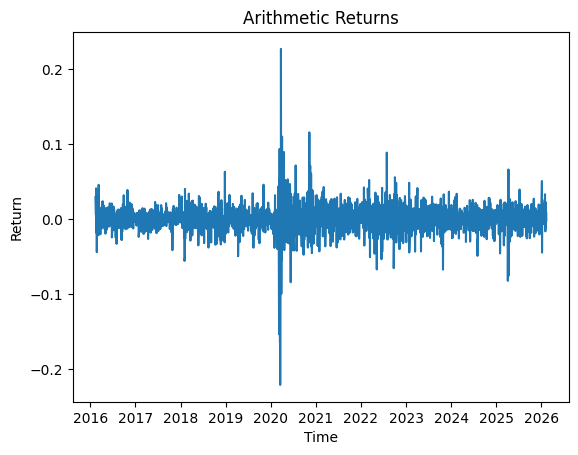

In [11]:
plt.plot(returns["R"])

plt.title("Arithmetic Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

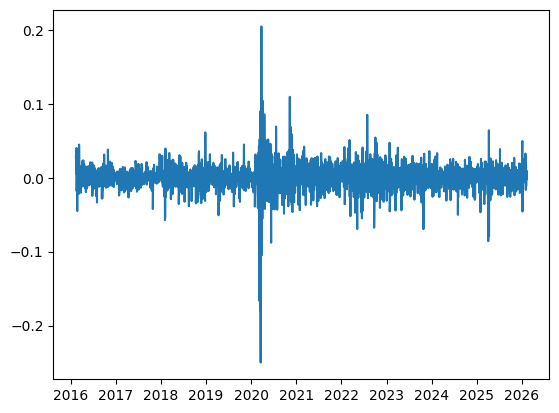

In [12]:
plt.plot(returns["r"])

plt.show()

## Test 1: Variances test

In [13]:
alpha = 0.05

w, p_value = stats.levene(returns["R"], returns["r"])

if p_value < alpha:
    print("Varianzas diferentes")
else:
    print("Varianzas iguales")

Varianzas iguales


## Test 2: Mean test

In [14]:
w, p_value = stats.ttest_ind(returns["R"]-returns["r"], 0)

if p_value < alpha:
    print("Medias diferentes")
else:
    print("Medias iguales")

Medias iguales


since the test is failed, we need test if the following relations is hold

$$
R_t - \frac{\sigma^2}{2} = r_t
$$

whether the above ecuation is true. Then it implice that

$$
R_t \neq r_t
$$

So, we continue with our stock model

In [15]:
r_t = returns["R"] - ((returns["R"]**2)/2)

In [16]:
w, p_value = stats.ttest_ind(r_t, returns["R"])

if p_value < 0.05:
    print("Medias diferentes")
else:
    print("Medias iguales")

Medias iguales


So, we could said that both means are equal and we continue with our process

## Test 3: ML test over data

Using the Maximun Likelihood to estimate the best distributions from the data.

This test will help us to find which distributions have the best fit from the data to calculate probabilities and validate assumptions

$$
L(\theta; x_1,\dots,x_n) \;=\; \prod_{i=1}^{n} f(x_i\mid \theta)
$$

In [17]:
from cuantis_utils.TestDistribuitions import best_fit_distribution, DEFAULT_DISTRIBUTIONS

In [18]:
test_distributions = DEFAULT_DISTRIBUTIONS[:20]

In [19]:
name_best_distribution_R, best_params_dist_R = best_fit_distribution(returns["R"], distributions=test_distributions)
name_best_distribution_R, best_params_dist_R

('nct',
 (np.float64(3.0116898022541),
  np.float64(-0.08639594849029168),
  np.float64(0.0019103333127156617),
  np.float64(0.010763907630330909)))

In [20]:
name_best_distribution_r, best_params_dist_r = best_fit_distribution(returns["r"], distributions=test_distributions)
name_best_distribution_r, best_params_dist_r

('nct',
 (np.float64(3.0045032585623996),
  np.float64(-0.13092805667688612),
  np.float64(0.0024385417959306563),
  np.float64(0.010742471370233483)))

### PDF

In [21]:
from cuantis_utils.TestDistribuitions import make_pdf

In [22]:
best_dist_R = getattr(stats, name_best_distribution_R)
best_dist_r = getattr(stats, name_best_distribution_r)

In [23]:
pdf_R = make_pdf(best_dist_R, best_params_dist_R, size = 4000)
pdf_r = make_pdf(best_dist_r, best_params_dist_r, size = 4000)

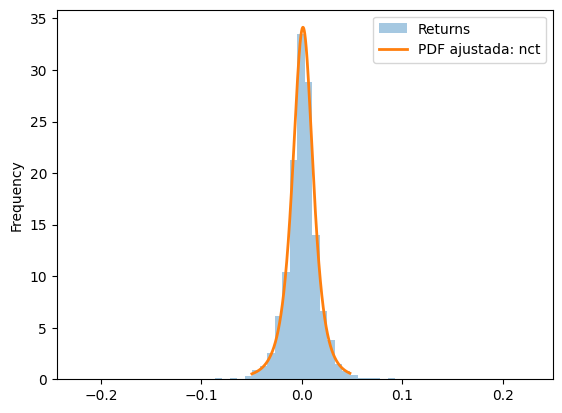

In [24]:
ax = pd.Series(returns["R"]).plot(kind="hist", bins=60, density=True, alpha=0.4, label="Returns")
pdf_R.plot(ax=ax, lw=2, label=f"PDF ajustada: {name_best_distribution_R}")
ax.legend()
plt.show()

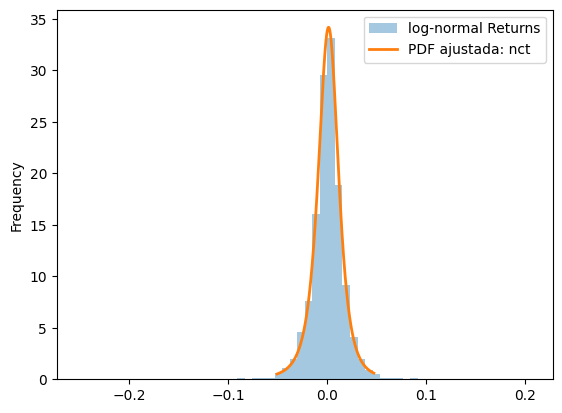

In [25]:
ax = pd.Series(returns["r"]).plot(kind="hist", bins=60, density=True, alpha=0.4, label="log-normal Returns")
pdf_r.plot(ax=ax, lw=2, label=f"PDF ajustada: {name_best_distribution_r}")
ax.legend()
plt.show()

The results show that both arithmetic and logarithmic returns are better fitted by an nct (non-central t) distribution than by a normal distribution. Although the tests were applied correctly and produced favorable results in terms of the statistical procedure, this suggests that, for the selected asset, log returns do not fully satisfy the normality assumption. Even so, the nct distribution is related to the normal family and can be interpreted as an extension that better captures these deviations.


# 5. Implement Model 1 and Random walk

Implement Model 1 in python and develop a single random walk. Use the same stock as in Homework 4.1 to get the parameters for the model: µ, σ.

- Add a plot to show the stock’s historical prices and your random walk from model 1.
- Feel free to add mores plots that you consider relevant
- Perform the hypothesis tests from previous homework to the random walk.
- Draw some conclusions

After the result from the fit distribution of the returns, we could use the normal distribution.

In [26]:
S0 = prices.iloc[0,0]

mu = returns["R"].mean()
sigma = returns["R"].std()

In [27]:
k = len(prices)

In [28]:
results_model = np.zeros(k)

results_model[0] = S0

In [29]:
results_model

array([53.57904816,  0.        ,  0.        , ...,  0.        ,
        0.        ,  0.        ], shape=(2514,))

## Model 1

This model is describe by the following ecuation

$$
S_t = S_0e^{(\mu - \frac{1}{2}\sigma^2) +  \sigma W_t}
$$

In [50]:
#Random Walk
W = np.random.normal(loc = 0, scale = 1, size = k)
W

shape_arg = best_params_dist_R[:-2]
loc = best_params_dist_R[-2]
scale = best_params_dist_R[-1]

result = best_dist_R(*shape_arg, loc = loc, scale = scale)
W1 = result.rvs(size = k)
W1

W

type(result)

scipy.stats._distn_infrastructure.rv_continuous_frozen

In [31]:
print(loc, scale)

0.0019103333127156617 0.010763907630330909


In [32]:
for i in range(1, k):
    results_model[i] = results_model[i-1] * ( np.exp(mu - 0.5*sigma**2) + sigma*W[i-1])

In [33]:
results_model = pd.DataFrame(results_model, index=prices["CVX"].index, columns=["Simulation"])

results_model.head(3)

,Simulation
Date,
2016-02-11,53.58
2016-02-12,53.06
2016-02-16,51.77


In [34]:
df_plot = pd.concat([results_model, prices["CVX"]], axis=1)
df_plot

,Simulation,CVX
Date,,
2016-02-11,53.58,53.58
2016-02-12,53.06,55.15
2016-02-16,51.77,55.45
2016-02-17,51.87,57.74
2016-02-18,51.68,56.70
...,...,...
2026-02-04,84.48,179.47
2026-02-05,86.10,177.49
2026-02-06,84.31,179.11


<Figure size 1200x500 with 0 Axes>

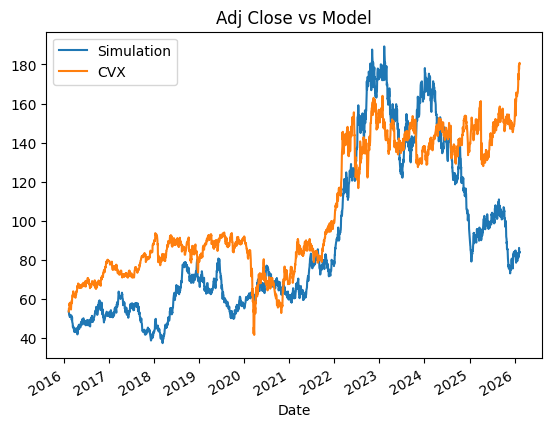

In [35]:
plt.figure(figsize=(12,5))

df_plot.plot(title="Adj Close vs Model")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.grid(True, alpha=0.3)

In [36]:
def step_stock_price(steps : int, S0 : float):
    result = np.zeros(steps)
    result[0] = S0
    return result


def simulation_step(simulations : int, steps : int, S0 : float):
    return [step_stock_price(steps,S0) for simulation in range(simulations)]


def simulations_stock_price(prices : pd.Series, simulations : int = 100, steps : int = 1000):
    S0 = prices.iloc[0]
    
    returns = prices.pct_change().dropna()
    
    mu = returns.mean()
    sigma = returns.std()
    
    result_model = simulation_step(simulations, steps, S0)
    
    W1 = [np.random.normal(loc = 0, scale = 1, size = steps) for i in range(simulations)]
    W = [result.rvs(size = k) for i in range(simulations)]
    
    for simulation in range(simulations):
        for step in range(1, steps):
            mu_model = np.exp(mu - 0.5*sigma**2)
            sigma_model = sigma*W[simulation][step - 1]
            result_model[simulation][step] =  result_model[simulation][step-1] * (mu_model + sigma_model)
    
    return np.array(result_model)

In [37]:
asset = prices["CVX"]

results_simulations_model = simulations_stock_price(asset, simulations=100, steps=len(asset))

In [38]:
df_results_simulations_model = pd.DataFrame(results_simulations_model.T, index = prices.CVX.index)
df_results_simulations_model.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Date,,,,,,,,,,,,,,,,,,,,,
2016-02-11,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,...,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58
2016-02-12,53.60,53.62,53.61,53.56,53.61,53.61,53.57,53.62,53.59,53.62,...,53.60,53.60,53.63,53.61,53.60,53.60,53.62,53.63,53.59,53.60
2016-02-16,53.64,53.65,53.62,53.57,53.64,53.63,53.59,53.59,53.60,53.64,...,53.61,53.61,53.60,53.63,53.65,53.62,53.65,53.67,53.62,53.62
2016-02-17,53.68,53.68,53.66,53.59,53.66,53.62,53.63,53.62,53.63,53.66,...,53.65,53.64,53.65,53.68,53.67,53.64,53.68,53.70,53.65,53.60
2016-02-18,53.70,53.70,53.67,53.62,53.68,53.65,53.67,53.69,53.65,53.70,...,53.66,53.66,53.68,53.69,53.68,53.64,53.71,53.72,53.65,53.63


In [39]:
df_plot = pd.concat([asset, df_results_simulations_model], axis = 1)
df_plot

,CVX,0,1,2,3,4,5,6,7,8,...,90,91,92,93,94,95,96,97,98,99
Date,,,,,,,,,,,,,,,,,,,,,
2016-02-11,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,...,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58,53.58
2016-02-12,55.15,53.60,53.62,53.61,53.56,53.61,53.61,53.57,53.62,53.59,...,53.60,53.60,53.63,53.61,53.60,53.60,53.62,53.63,53.59,53.60
2016-02-16,55.45,53.64,53.65,53.62,53.57,53.64,53.63,53.59,53.59,53.60,...,53.61,53.61,53.60,53.63,53.65,53.62,53.65,53.67,53.62,53.62
2016-02-17,57.74,53.68,53.68,53.66,53.59,53.66,53.62,53.63,53.62,53.63,...,53.65,53.64,53.65,53.68,53.67,53.64,53.68,53.70,53.65,53.60
2016-02-18,56.70,53.70,53.70,53.67,53.62,53.68,53.65,53.67,53.69,53.65,...,53.66,53.66,53.68,53.69,53.68,53.64,53.71,53.72,53.65,53.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-04,179.47,183.90,183.80,189.28,184.66,185.33,190.48,184.31,185.64,188.87,...,189.14,183.78,177.55,189.76,181.29,188.47,189.82,188.06,186.15,189.33
2026-02-05,177.49,183.94,183.89,189.35,184.61,185.42,190.51,184.48,185.67,189.00,...,189.23,183.87,177.66,189.85,181.40,188.49,189.93,188.20,186.22,189.38
2026-02-06,179.11,183.91,184.01,189.45,184.70,185.50,190.57,184.50,185.80,189.08,...,189.25,184.15,177.77,189.90,181.49,188.51,190.01,188.31,186.32,189.47


The real trayectory from the price of CVX asset is the black line

<Figure size 640x480 with 0 Axes>

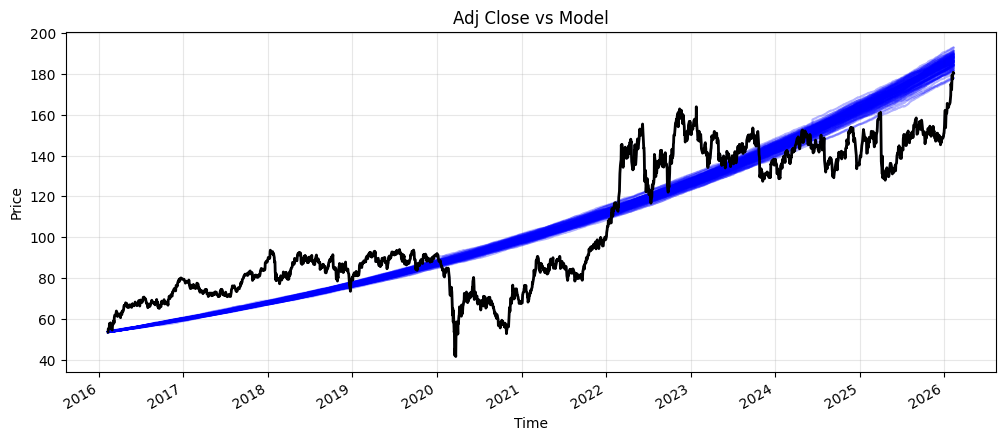

In [40]:
plt.figure()

ax = df_plot.plot(figsize=(12,5), title="Adj Close vs Model", legend=False, alpha=0.3, color="blue")
df_plot["CVX"].plot(ax = ax, color = "black", lw = 2, label = "CVX")

ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
plt.show()

## Test hypothesis over Random Walk

In [41]:
from cuantis_utils.Model1HypothesisTester import Model1HypothesisTester

In [42]:
random_walk_model = df_plot.iloc[:, 1]

In [43]:
random_walk_tester = Model1HypothesisTester(price_series=random_walk_model, distributions=test_distributions)
random_walk_returns = Model1HypothesisTester(price_series=random_walk_model, distributions=test_distributions)

### Test 1: Variances test

In [44]:
# Leven Test fomr variance equality

random_walk_test_variance = random_walk_tester.test_variance_equality()
random_walk_test_variance.p_value, random_walk_test_variance.decision

(0.9898044805034156, 'Varianzas iguales')

### Test 2: Mean test

In [45]:
# Ttest mean are different

random_walk_test_mean = random_walk_tester.test_mean_difference()
random_walk_test_mean.p_value, random_walk_test_mean.decision

(7.831020516467747e-166, 'Medias diferentes')

In [46]:
returns_random_walk = random_walk_tester._get_returns()

In [47]:
r_t = returns_random_walk["R"] - ((returns_random_walk["R"]**2)/2)

w, p_value = stats.ttest_ind(r_t, returns["R"])

if p_value < 0.05:
    print("Medias diferentes")
else:
    print("Medias iguales")

Medias iguales


### Test 3: ML test over data

In [48]:
random_walk_name_dist = random_walk_tester.fit_distributions()
random_walk_name_dist["name_best_distribution_R"]

't'

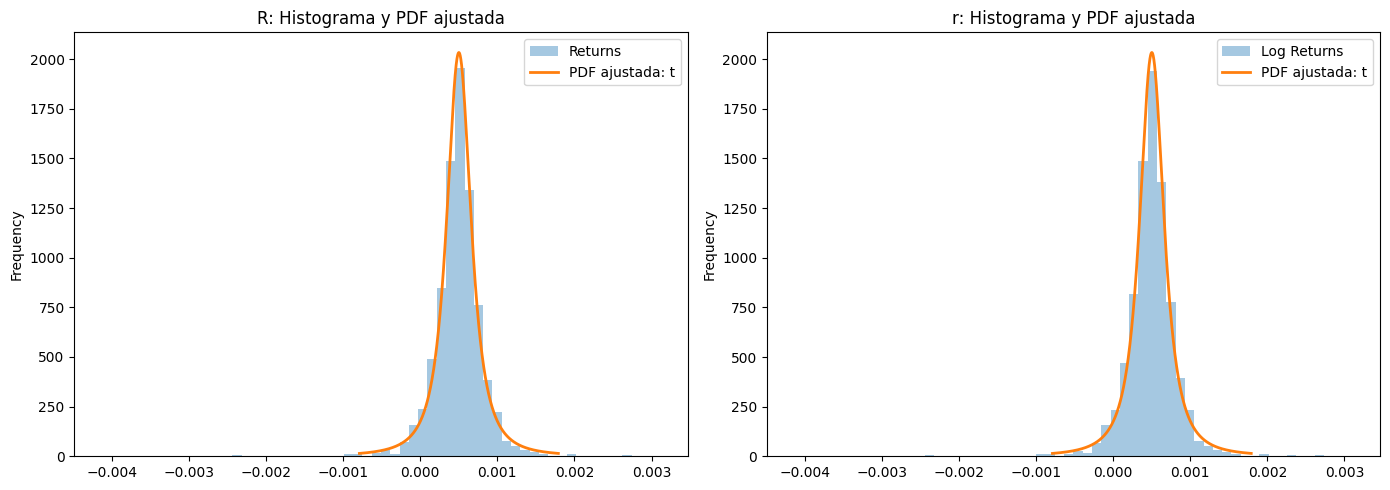

In [49]:
random_walk_tester.plot_fitted_distributions()
plt.show()

## Conclutions

In section 5 you implement “Model 1” for stock prices using CVX. The code sets the initial price `S0` and calibrates `μ` and `σ` from the historical arithmetic returns (`R`) via their sample mean and standard deviation. With these parameters it generates a random walk (one path and then multiple simulated paths) and overlays them against the real adjusted close series. This comparison shows how a single simulated path can drift far from the realized trajectory; in your run the simulated level ends well below the observed price (e.g., 2026-02-10: ~75.93 vs ~182.26), highlighting both the intrinsic variability of the process and the limitations of calibrating the model only through historical mean and volatility.

You then run hypothesis tests on the random walk: Levene’s test does not indicate different variances between `R` and `r` (p≈0.992), but the mean test on `(R−r)` strongly rejects a zero mean (p≈8.46×10⁻214), meaning arithmetic and log returns are not interchangeable on average. The additional small-return approximation check `r_t ≈ R_t − R_t^2/2` does not detect a mean difference versus `R` in that sample (“equal means”). Finally, distribution fitting selects `loggamma` as the best fit for simulated `R`, supporting the idea that Gaussian assumptions are a convenient baseline but can miss heavy tails. A key modeling caveat is the price update rule: the random shock is placed outside the exponential term (unlike standard GBM), which materially changes the dynamics and therefore the interpretation of fit and test outcomes.
